In [1]:
import os
import qsprpred

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [8]:
os.makedirs("dataset_outputs/A2AR/data", exist_ok=True)

# Create dataset
dataset = QSPRDataset.fromTableFile(
    filename="data/src/datasets/a2ar/data/A2AR.csv",
    store_dir="dataset_outputs/A2AR/data",
    name="A2ARDataset",
    target_props=[{"name": "Y", "task": "SINGLECLASS", "th": [0.5]}],
    random_state=42,
    smiles_col = 'Drug',
    sep=','
)

In [11]:
dataset.X

""
QSPRID
A2ARDataset_0000
A2ARDataset_0001
A2ARDataset_0002
A2ARDataset_0003
A2ARDataset_0004
...
A2ARDataset_4077
A2ARDataset_4078
A2ARDataset_4079


In [6]:
dataset.prepareDataset(
    feature_calculators=[MorganFP(radius=2, nBits=4096)],
    recalculate_features=True,
)

In [7]:
dataset.X

,MorganFP_MorganFP_0,MorganFP_MorganFP_1,MorganFP_MorganFP_2,MorganFP_MorganFP_3,MorganFP_MorganFP_4,MorganFP_MorganFP_5,MorganFP_MorganFP_6,MorganFP_MorganFP_7,MorganFP_MorganFP_8,MorganFP_MorganFP_9,...,MorganFP_MorganFP_4086,MorganFP_MorganFP_4087,MorganFP_MorganFP_4088,MorganFP_MorganFP_4089,MorganFP_MorganFP_4090,MorganFP_MorganFP_4091,MorganFP_MorganFP_4092,MorganFP_MorganFP_4093,MorganFP_MorganFP_4094,MorganFP_MorganFP_4095
QSPRID,,,,,,,,,,,,,,,,,,,,,
A2ARDataset_0599,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
A2ARDataset_0752,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
A2ARDataset_1954,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
A2ARDataset_2928,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
A2ARDataset_2512,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2ARDataset_1130,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
A2ARDataset_1294,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
A2ARDataset_0860,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [5]:
from qsprpred.data.descriptors.sets import RDKitDescs

rdkit_descs = RDKitDescs()

dataset.addDescriptors([rdkit_descs])

dataset.descriptorSets

In [6]:

# Přidejte cestu k vašemu lokálnímu repozitáři
import sys
import os

# Přidání cesty k lokálnímu repozitáři na začátek sys.path
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred')

# Zkontrolujte, zda je cesta v sys.path
print(sys.path)

from importlib import reload

# Znovu proveďte import
from qsprpred.extra.gpu.models.neural_network import STFullyConnected
# Znovu načtěte modul, abyste zajistili, že je správně importován
reload(sys.modules['qsprpred.extra.gpu.models.neural_network'])

# Znovu proveďte import
from qsprpred.extra.gpu.models.neural_network import STFullyConnected

os.chdir('/home/ubuntu/Bakalarka/QSPRpred')
print(os.getcwd())


import sys
import importlib.util

# Přidání cesty k repozitáři do sys.path
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred')

# Specifikujte cestu k souboru, který chcete importovat
module_path = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/neural_network.py'
module_name = 'qsprpred.extra.gpu.models.neural_network'

# Načtěte modul z konkrétní cesty
spec = importlib.util.spec_from_file_location(module_name, module_path)
neural_network = importlib.util.module_from_spec(spec)
spec.loader.exec_module(neural_network)

# Nyní můžete používat třídu STFullyConnected
STFullyConnected = neural_network.STFullyConnected

['/home/ubuntu/Bakalarka/QSPRpred', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python311.zip', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/lib-dynload', '', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages']
/home/ubuntu/Bakalarka/QSPRpred
lol


In [7]:
from sklearn.model_selection import ParameterGrid
from torch.nn import functional as F
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
import pandas as pd
def test_fun(dic,  X_train, y_train, X_test, y_test) -> pd.DataFrame:
    param_grid_t = ParameterGrid(dic)
    i = 0
    val_f1_t = []
    val_acc_t = []
    param_len_t = len(param_grid_t)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Device used:", device)
    for param in param_grid_t:
        i += 1
        print(i, '/', param_len_t)
        model_sts_t = STFullyConnected(n_dim=X_train.shape[1],  # počet vstupních neuronů (počet deskriptorů)
        n_class=1,  # regresní úloha (1 výstup)
        gpus=[],
        device=device,
        is_reg=False, **param)
        model_sts_t.fit(X_train, y_train)
        res = model_sts_t.predict(X_test)
        res = res >0.5
        val_f1_t.append(f1_score(res, y_test))
        val_acc_t.append(accuracy_score(res, y_test))
        print(param)
        print(f1_score(res, y_test))
        print(accuracy_score(res, y_test))
    my_df = pd.DataFrame(param_grid_t)
    my_df["F1"] = val_f1_t
    my_df["Acc"] = val_acc_t
    return my_df

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

X = dataset.X
X1, X2, y1, y2 = train_test_split(dataset.X, dataset.y, test_size=0.25, random_state=42)
X3 = dataset.X_ind
y3 = dataset.y_ind

imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
X1 = imp_mean.fit_transform(X1)
X2 = imp_mean.transform(X2)
X3 = imp_mean.transform(X3)

scaler = StandardScaler()
X1 = scaler.fit_transform(X1)
X2 = scaler.transform(X2)
X3 = scaler.transform(X3)



In [9]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=0.5, random_state=42)
X1, y1 = smote.fit_resample(X1, y1)
display(pd.DataFrame(X1))


,0,1,2,3,4,5,6,7,8,9,...,4296,4297,4298,4299,4300,4301,4302,4303,4304,4305
0,-0.040456,0.0,-0.099504,-0.020215,-0.070186,-0.053551,-0.067184,-0.603779,-0.111386,0.0,...,-0.145865,-0.060746,-0.088443,-0.116896,-0.359386,0.0,-0.281971,-0.181096,-0.225319,1.980336
1,-0.040456,0.0,-0.099504,-0.020215,-0.070186,-0.053551,-0.067184,-0.603779,-0.111386,0.0,...,-0.145865,-0.060746,-0.088443,-0.116896,-0.359386,0.0,2.943564,-0.181096,-0.225319,-0.258817
2,-0.040456,0.0,-0.099504,-0.020215,-0.070186,-0.053551,-0.067184,-0.603779,-0.111386,0.0,...,-0.145865,-0.060746,-0.088443,-0.116896,-0.359386,0.0,-0.281971,-0.181096,-0.225319,0.213839
3,-0.040456,0.0,-0.099504,-0.020215,-0.070186,-0.053551,-0.067184,-0.603779,-0.111386,0.0,...,-0.145865,-0.060746,-0.088443,-0.116896,-0.359386,0.0,-0.281971,-0.181096,-0.225319,1.331313
4,-0.040456,0.0,-0.099504,-0.020215,-0.070186,-0.053551,-0.067184,-0.603779,-0.111386,0.0,...,-0.145865,-0.060746,-0.088443,-0.116896,-0.359386,0.0,-0.281971,-0.181096,4.222915,-2.480443
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3533,-0.040456,0.0,-0.099504,-0.020215,-0.070186,-0.053551,-0.067184,1.656237,-0.111386,0.0,...,-0.145865,-0.060746,-0.088443,-0.116896,-0.359386,0.0,-0.281971,-0.181096,-0.225319,0.403167
3534,-0.040456,0.0,-0.099504,-0.020215,-0.070186,10.614778,-0.067184,-0.603779,-0.111386,0.0,...,-0.145865,-0.060746,-0.088443,-0.116896,-0.359386,0.0,-0.281971,-0.181096,2.308674,1.306710
3535,-0.040456,0.0,-0.099504,-0.020215,-0.070186,-0.053551,-0.067184,1.656237,-0.111386,0.0,...,-0.145865,-0.060746,-0.088443,-0.116896,-0.359386,0.0,-0.281971,-0.181096,-0.225319,0.168575
3536,-0.040456,0.0,-0.099504,-0.020215,-0.070186,-0.053551,-0.067184,-0.603779,-0.111386,0.0,...,-0.145865,-0.060746,-0.088443,-0.116896,-0.359386,0.0,-0.281971,-0.181096,-0.225319,0.589209


In [10]:
test_par = {'weight_decay': 0.0001, 'patience': 75, 
            'neuron_layers':[1024, 512, 256, 128, 64, 32, 16, 8, 4],
            'n_epochs': 200, 'dropout_frac': 0.5,
            'act_fun': F.selu,
           "tol": 1e-5}
model_sts_3 = STFullyConnected(n_dim=X1.shape[1],  # počet vstupních neuronů (počet deskriptorů)
    n_class=1,  # regresní úloha (1 výstup)
    gpus=[],
    device="cuda",
    batch_size=256,is_reg=False, **test_par)
model_sts_3.fit(X1, y1)
res = model_sts_3.predict(X2)
res = res >0.5
print(f1_score(res, y2))

0.9811083123425692


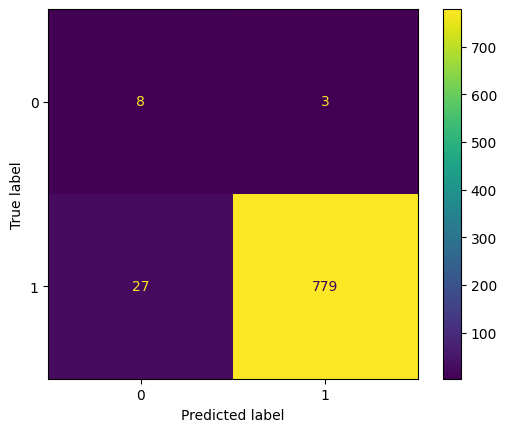

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
conf_mat = confusion_matrix(res, y2)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat)
disp.plot()

In [12]:
from sklearn.metrics import matthews_corrcoef
print(matthews_corrcoef(res, y2))

0.39486120346584


In [13]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("fill-mask", model="entropy/roberta_zinc_480m", device="cuda")

In [10]:
import torch

In [4]:
import torch
from transformers import RobertaTokenizerFast, RobertaForMaskedLM, DataCollatorWithPadding
from torch.utils.data import DataLoader, Dataset

# Nastavení zařízení (GPU nebo CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Načtení tokenizeru a modelu
tokenizer = RobertaTokenizerFast.from_pretrained("entropy/roberta_zinc_480m", max_len=128)
model = RobertaForMaskedLM.from_pretrained('entropy/roberta_zinc_480m')

# Přenesení modelu na správné zařízení
model.to(device)

# Připravení collatoru pro padding
collator = DataCollatorWithPadding(tokenizer, padding=True, return_tensors='pt')

# Načtení seznamu SMILES (například z nějaké jiné struktury než datasetu)
smiles = dataset.getDF()["Drug"] # Příklad seznamu SMILES, můžeš použít vlastní

# Vytvoření custom Dataset pro SMILES
class SMILESDataset(Dataset):
    def __init__(self, smiles, tokenizer, max_len=128):
        self.smiles = smiles
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        smile = self.smiles[idx]
        encoding = self.tokenizer(smile, truncation=True, padding='max_length', max_length=self.max_len, return_tensors='pt')
        return encoding

# Vytvoření datasetu
smiles_dataset = SMILESDataset(smiles, tokenizer)

# Vytvoření DataLoaderu (dávky po 32)
batch_size = 32
dataloader = DataLoader(smiles_dataset, batch_size=batch_size, collate_fn=collator)

# Zpracování dat po dávkách
model.eval()  # Převede model do evaluačního režimu (bez trénování)
embeddings_list = []  # Uchováme všechny embeddings

with torch.no_grad():  # Nevytvářet gradienty během evaluace
    for batch in dataloader:
        # Zkontroluj tvar batchů
        print("Batch input_ids tvar:", batch['input_ids'].shape)
        print("Batch attention_mask tvar:", batch['attention_mask'].shape)

        # Přenesení všech vstupů na správné zařízení (GPU nebo CPU)
        input_ids = batch['input_ids'].squeeze(1).to(device)  # Squeeze odstraní extra dimenzi
        attention_mask = batch['attention_mask'].squeeze(1).to(device)  # Squeeze odstraní extra dimenzi

        # Modelování výstupů s hidden states
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, output_hidden_states=True)

        # Získání poslední vrstvy hidden states
        full_embeddings = outputs[1][-1]

        # Výpočet průměrného embeddingu pro každý token
        embeddings = ((full_embeddings * attention_mask.unsqueeze(-1)).sum(1) / attention_mask.sum(-1).unsqueeze(-1))
        
        # Uložení embeddings pro tuto dávku
        embeddings_list.append(embeddings)

# Spojení všech embeddings z dávky do jednoho tensoru
all_embeddings = torch.cat(embeddings_list, dim=0)

# Teď můžeš použít `all_embeddings`, což obsahuje embeddings pro všechny SMILES v datasetu


/tmp/ipykernel_21750/161773021.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  smile = self.smiles[idx]


Batch input_ids tvar: torch.Size([32, 1, 128])
Batch attention_mask tvar: torch.Size([32, 1, 128])
Batch input_ids tvar: torch.Size([32, 1, 128])
Batch attention_mask tvar: torch.Size([32, 1, 128])
Batch input_ids tvar: torch.Size([32, 1, 128])
Batch attention_mask tvar: torch.Size([32, 1, 128])
Batch input_ids tvar: torch.Size([32, 1, 128])
Batch attention_mask tvar: torch.Size([32, 1, 128])
Batch input_ids tvar: torch.Size([32, 1, 128])
Batch attention_mask tvar: torch.Size([32, 1, 128])
Batch input_ids tvar: torch.Size([32, 1, 128])
Batch attention_mask tvar: torch.Size([32, 1, 128])
Batch input_ids tvar: torch.Size([32, 1, 128])
Batch attention_mask tvar: torch.Size([32, 1, 128])
Batch input_ids tvar: torch.Size([32, 1, 128])
Batch attention_mask tvar: torch.Size([32, 1, 128])
Batch input_ids tvar: torch.Size([32, 1, 128])
Batch attention_mask tvar: torch.Size([32, 1, 128])
Batch input_ids tvar: torch.Size([32, 1, 128])
Batch attention_mask tvar: torch.Size([32, 1, 128])
Batch inpu

In [5]:

display(all_embeddings)

tensor([[ 0.2189,  0.4461,  0.4186,  ..., -0.0437, -0.0287, -1.1057],
        [ 0.2651,  0.2228,  0.5488,  ..., -0.1060, -0.0188, -0.0067],
        [ 0.8735,  0.3554,  0.5385,  ..., -0.1421,  0.0058, -0.5140],
        ...,
        [ 0.1498,  0.1897,  0.5231,  ..., -0.3420,  0.1334,  0.1158],
        [ 0.1914,  0.1945,  0.8330,  ..., -0.0156, -0.3230, -0.4596],
        [ 0.1892,  0.1603,  0.6430,  ..., -0.0387,  0.5814, -0.2771]],
       device='cuda:0')

In [ ]:
dataset.X

In [46]:
from sklearn.model_selection import train_test_split

X, X3, y, y3 = train_test_split(all_embeddings, dataset.getDF().Y_original.tolist(), test_size=0.2, random_state=42)
X1, X2, y1, y2= train_test_split(X, y, test_size=0.25, random_state=42)

In [30]:
# Před trénováním se ujistíme, že model i data jsou na správném zařízení (GPU nebo CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Přenos modelu na správné zařízení
model_sts_3.to(device)

# Zkontrolujeme, že data jsou správně na GPU
for batch in train_loader:
    inputs, labels = [item.to(device) for item in batch]
    print(inputs.device, labels.device)
    break  # Testujeme pouze první dávku



cuda:0 cuda:0


In [28]:

test_par = {'weight_decay': 0.0001, 'patience': 75, 
            'neuron_layers':[1024, 512, 256, 128, 64, 32, 16, 8, 4],
            'n_epochs': 200, 'dropout_frac': 0.5,
            'act_fun': F.selu,
           "tol": 1e-5}
model_sts_3 = STFullyConnected(n_dim=X1.shape[1],  # počet vstupních neuronů (počet deskriptorů)
    n_class=1,  # regresní úloha (1 výstup)
    gpus=[],
    device="cuda",
    batch_size=256,is_reg=False, **test_par)
model_sts_3.fit(X1, y1)
res_v = model_sts_3.predict(X2)


TypeError: new(): data must be a sequence (got builtin_function_or_method)

In [31]:
model_sts_3.fit(X1, y1)

TypeError: new(): data must be a sequence (got builtin_function_or_method)

In [32]:
import numpy as np

print(type(X1))  # Mělo by to být <class 'numpy.ndarray'>
print(type(y1))  # Mělo by to být <class 'numpy.ndarray'>


<class 'torch.Tensor'>
<class 'torch.Tensor'>


In [55]:
#X1 = X1.cpu().numpy()
#y1 = y1.cpu().numpy()
#X2 = X1.cpu().numpy()
#y2 = y1.cpu().numpy()
#X3 = X1.cpu().numpy()
#y3 = y1.cpu().numpy()
y1 = np.array(y1)
y2 = np.array(y2)
y3 = np.array(y3)
y1 = y1.reshape(-1, 1)
y2 = y2.reshape(-1, 1)
y3 = y3.reshape(-1, 1)

In [57]:
X2 = X2.cpu().numpy()

In [37]:
import numpy as np

# Přidání dimenze pomocí np.newaxis
y1 = y1[:, np.newaxis]

# Nebo pomocí reshape
y1 = y1.reshape(-1, 1)


In [38]:
model_sts_3.fit(X1, y1)

(STFullyConnected(
   (layers): ModuleList(
     (0): Linear(in_features=768, out_features=1024, bias=True)
     (1): Linear(in_features=1024, out_features=512, bias=True)
     (2): Linear(in_features=512, out_features=256, bias=True)
     (3): Linear(in_features=256, out_features=128, bias=True)
     (4): Linear(in_features=128, out_features=64, bias=True)
     (5): Linear(in_features=64, out_features=32, bias=True)
     (6): Linear(in_features=32, out_features=16, bias=True)
     (7): Linear(in_features=16, out_features=8, bias=True)
     (8): Linear(in_features=8, out_features=4, bias=True)
     (9): Linear(in_features=4, out_features=1, bias=True)
   )
   (dropout): Dropout(p=0.5, inplace=False)
   (criterion): BCELoss()
   (final_layer_activation): Sigmoid()
 ),
 0)

In [40]:

X2 = X2.cpu().numpy()

res_v = model_sts_3.predict(X2)

In [45]:
print("xd")

xd


In [ ]:

from torch import optim
my_dict_ult_5 = {
    "act_fun": [F.selu],
    "dropout_frac": [ 0, 0.2, 0.4, 0.6, ],
    "patience": [75],
    "tol": [1e-5],
    "weight_decay": [1e-4],
    "n_epochs": [200, 400, 600],
    "neuron_layers": [[4096, 2048, 2048, 512, 128],   [4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8], [7500, 2500], [5000]]
    , "batch_size": [256, 128]
    , "optimizer": [optim.AdamW, optim.RMSprop],
    "lr": [1e-4, 1e-3, 1e-5]
}
df_batch_ult_5 = test_fun(my_dict_ult_5, X1, y1, X2, y2) 

Device used: cuda
1 / 576
{'act_fun': <function selu at 0x7f0851e9d800>, 'batch_size': 256, 'dropout_frac': 0, 'lr': 0.0001, 'n_epochs': 200, 'neuron_layers': [4096, 2048, 2048, 512, 128], 'optimizer': <class 'torch.optim.adamw.AdamW'>, 'patience': 75, 'tol': 1e-05, 'weight_decay': 0.0001}
0.9777211966900063
0.9571603427172583
2 / 576
{'act_fun': <function selu at 0x7f0851e9d800>, 'batch_size': 256, 'dropout_frac': 0, 'lr': 0.0001, 'n_epochs': 200, 'neuron_layers': [4096, 2048, 2048, 512, 128], 'optimizer': <class 'torch.optim.rmsprop.RMSprop'>, 'patience': 75, 'tol': 1e-05, 'weight_decay': 0.0001}
0.9777495232040686
0.9571603427172583
3 / 576
{'act_fun': <function selu at 0x7f0851e9d800>, 'batch_size': 256, 'dropout_frac': 0, 'lr': 0.0001, 'n_epochs': 200, 'neuron_layers': [4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8], 'optimizer': <class 'torch.optim.adamw.AdamW'>, 'patience': 75, 'tol': 1e-05, 'weight_decay': 0.0001}
0.9805153991200503
0.9620563035495716
4 / 576
{'act_fun': <func

In [ ]:
df_batch_ult_5.sort_values(by="F1", ascending=False, inplace=True)
df_batch_ult_5.to_csv('qsprpred/extra/gpu/models/dataset_outputs/A2AR/tabs/A2ARbatch6.csv')